In [1]:
!pip install gradio
!pip install langchain==0.3.14
!pip install langchain-openai==0.3.0
!pip install langchain-community==0.3.14
!pip install langgraph==0.2.66
!pip install langchain-experimental==0.3.4
!apt-get install sqlite3 -y
!pip install --force-reinstall pandas numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 326.9/326.9 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 60.3 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: langsmith
    Found existing installat

In [42]:
import pandas as pd
import gradio as gr
from langchain_openai import ChatOpenAI
from langchain.schema import AIMessage, HumanMessage
from langchain_community.utilities import SQLDatabase
from langchain_community.agent_toolkits import SQLDatabaseToolkit
from langchain_openai import ChatOpenAI


from typing import Any, Generator, Literal, Optional
from typing_extensions import TypedDict



from langchain_core.runnables import RunnableLambda
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import create_react_agent, ToolNode, tools_condition

from pydantic import BaseModel

from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool
from langchain_core.messages import trim_messages, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from typing import Annotated
import plotly.graph_objects as go #To uPse the Plotly library to create the graph
import plotly.express as px #To use the Plotly Express library to create the graph


In [43]:
from google.colab import userdata
OPENAI_KEY = userdata.get('OPENAI_API_KEY')

In [3]:
#!sqlite3 --version

In [44]:
import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

In [5]:
# in case of issues download from https://drive.google.com/file/d/16mZm3C7xKpPqp_86e64uzduLpM5mPUdq/view?usp=sharing and upload
#!gdown 16mZm3C7xKpPqp_86e64uzduLpM5mPUdq

In [6]:
#!sqlite3 ComicStore.db ".read ./comicdb_create_script.sql"

In [45]:
repl = PythonREPL()

In [46]:
repl = PythonREPL()
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute code to generate plots, charts and visualizations. Use only plotly express to generate charts."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.
    To generate charts, you must use ONLY plotly express.
    Follow the instructions in the code output:
    1. The figure sizes should by 5 by 3. Select different colours and styles.
    2. import all necessary packages in the code.
    """
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\n\n {result}"
    return result_str

In [35]:
#db = SQLDatabase.from_uri("sqlite:///ComicStore.db")
#chatgpt = ChatOpenAI(model="gpt-4o", temperature=0)
#sql_toolkit = SQLDatabaseToolkit(db=db, llm=chatgpt)
#sql_tools = sql_toolkit.get_tools()

#agent_tools = [sql_tools, python_repl_tool]

In [47]:
from langchain_core.messages import SystemMessage

AGENT_SYS_PROMP = """Role: You are biomarker assistant tasked with providing up-to-date information about the clinical trial data.

Objective: Assist data-driven researchers by giving accurate information about the clinical trial data.

Capabilities: You have been given a tool called get_data_from_genie. Please retrieve your data only from this tool. Do not construct any query.

Next Steps: Use the python_repl_tool to generate visualizations and charts. Use plotly express to generate charts. The plotting figure sizes should by 5 by 3. Select different colours and styles.
"""

In [48]:
@tool
def get_data_from_database(prompt: str):
    """Retrieve data from database on the prompt request"""

    query_description = '''This analysis provides the average age of participants,
    categorized by their dose sequence. The results focus on groups
    where the dose sequence is specified, allowing for insights into age distribution across different dosing protocols.
    '''

    query='''SELECT `DOSESEQP`, AVG(`AGE`) AS `average_age`
    FROM `patient_profile`
    GROUP BY `DOSESEQP` HAVING `DOSESEQP` IS NOT NULL
    '''

    sql_query = f"\n```SQL\n{query}\n```\n\n"

    average_age_data = {
    'DOSESEQP': [160, 10, 80, 40],
    'average_age': [50.0714, 49.2619, 44.2778, 41.2308]}

    data_df = pd.DataFrame(average_age_data)

    output = (query_description + """:\n\n """ +
          data_df.to_markdown() +
          """ \n\n """ + sql_query)

    return output

In [49]:
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent
from langchain_openai import ChatOpenAI


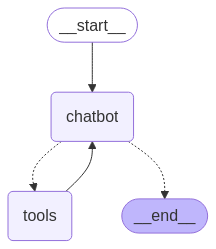

In [50]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tools = [get_data_from_database, python_repl_tool]




llm = ChatOpenAI(model="gpt-4o", temperature=0)

llm_with_tools = llm.bind_tools(tools)

SYS_MSG = SystemMessage(content=AGENT_SYS_PROMP)

def chatbot(state: State):

    return {"messages": [llm_with_tools.invoke([SYS_MSG] + state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools = tools)
graph_builder.add_node('tools', tool_node)
graph_builder.add_conditional_edges('chatbot',
                                    tools_condition,
                                    ['tools', END]
                                    )
graph_builder.add_edge('tools', 'chatbot')
graph_builder.set_entry_point('chatbot')

memory = MemorySaver()

#compiled_graph = graph_builder.compile(checkpointer=memory)
text2sql_agent = graph_builder.compile()

text2sql_agent

In [26]:
event  = text2sql_agent.invoke({"messages": [HumanMessage(content="Get average age by Dose?")]})

In [27]:
 event["messages"][-1].pretty_print()

================================== Ai Message ==================================

The average age of participants by dose sequence is visualized in the bar chart above. Here's a summary of the data:

- Dose Sequence 160: Average Age = 50.07
- Dose Sequence 10: Average Age = 49.26
- Dose Sequence 80: Average Age = 44.28
- Dose Sequence 40: Average Age = 41.23

The chart provides a visual representation of how the average age varies across different dose sequences.


In [28]:
from IPython.display import display, Markdown

for event in text2sql_agent.stream(
    {"messages": [HumanMessage(content="Get average age by Dose?")]},
    stream_mode='values' #returns full agent state with all messages including updates
):
    event["messages"][-1].pretty_print()

print('\n\nFinal Response:\n')
display(Markdown(event["messages"][-1].content))

================================ Human Message =================================

Get average age by Dose?
================================== Ai Message ==================================
Tool Calls:
  get_data_from_database (call_3eQgNFwd2uoxoXiCnp6syGxI)
 Call ID: call_3eQgNFwd2uoxoXiCnp6syGxI
  Args:
    prompt: average age by Dose
================================= Tool Message =================================
Name: get_data_from_database

This analysis provides the average age of participants, 
    categorized by their dose sequence. The results focus on groups 
    where the dose sequence is specified, allowing for insights into age distribution across different dosing protocols.
    :

 |    |   DOSESEQP |   average_age |
|---:|-----------:|--------------:|
|  0 |        160 |       50.0714 |
|  1 |         10 |       49.2619 |
|  2 |         80 |       44.2778 |
|  3 |         40 |       41.2308 | 

 
```SQL
SELECT `DOSESEQP`, AVG(`AGE`) AS `average_age` 
    FROM `patient_prof

================================== Ai Message ==================================
Tool Calls:
  python_repl_tool (call_1VvLUmddAwvE1RX90TVDkHhE)
 Call ID: call_1VvLUmddAwvE1RX90TVDkHhE
  Args:
    code: import plotly.express as px
import pandas as pd

# Data for average age by dose
average_age_data = {
    'DOSESEQP': [160, 10, 80, 40],
    'average_age': [50.0714, 49.2619, 44.2778, 41.2308]
}

# Create a DataFrame
average_age_df = pd.DataFrame(average_age_data)

# Create a bar chart
fig = px.bar(average_age_df, x='DOSESEQP', y='average_age', 
             title='Average Age by Dose', 
             labels={'DOSESEQP': 'Dose Sequence', 'average_age': 'Average Age'},
             color='average_age',
             color_continuous_scale='Viridis')

# Update layout for better visualization
fig.update_layout(width=500, height=300)

fig.show()
================================= Tool Message =================================
Name: python_repl_tool

Successfully executed:
```python
import plotly

The average age of participants categorized by their dose sequence is visualized in the bar chart above. The data shows the following average ages for each dose sequence:

- Dose Sequence 160: Average Age 50.07
- Dose Sequence 10: Average Age 49.26
- Dose Sequence 80: Average Age 44.28
- Dose Sequence 40: Average Age 41.23

The chart provides a clear visual representation of how the average age varies across different dosing protocols.

In [52]:
def predict(message, history):
    #history.append({"role": "user", "content": message})
    chunks = []
    for event in text2sql_agent.stream(
    #{"messages": [HumanMessage(content=message)]},
    {"messages":[{"role": "user", "content": message}]},
    stream_mode='values' ):
      chunks.append(event["messages"][-1].content or "")
      yield "".join(chunks)

    return

demo = gr.ChatInterface(
    predict,
    type="messages"
)




In [53]:
demo.launch(debug=True)

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://429d11c38f7d7e6ec3.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://429d11c38f7d7e6ec3.gradio.live


In [1]:
import pandas as pd
import gradio as gr
from langchain_openai import ChatOpenAI




from typing import Any, Generator, Literal, Optional
from typing_extensions import TypedDict



from langchain_core.runnables import RunnableLambda
from langgraph.graph import END, StateGraph
from langgraph.graph.message import add_messages
from langgraph.graph.state import CompiledStateGraph
from langgraph.prebuilt import create_react_agent, ToolNode, tools_condition

from pydantic import BaseModel

from langgraph.prebuilt import create_react_agent


from langchain_experimental.utilities import PythonREPL
from langchain_core.tools import tool
from langchain_core.messages import trim_messages, SystemMessage
from langgraph.checkpoint.memory import MemorySaver
from typing import Annotated
import plotly.graph_objects as go #To uPse the Plotly library to create the graph
import plotly.express as px #To use the Plotly Express library to create the graph

In [ ]:
from google.colab import userdata
OPENAI_KEY = userdata.get('OPENAI_API_KEY')

import os

os.environ['OPENAI_API_KEY'] = OPENAI_KEY

repl = PythonREPL()
@tool
def python_repl_tool(
    code: Annotated[str, "The python code to execute code to generate plots, charts and visualizations. Use only plotly express to generate charts."],
):
    """Use this to execute python code. If you want to see the output of a value,
    you should print it out with `print(...)`. This is visible to the user.
    To generate charts, you must use ONLY plotly express.
    Follow the instructions in the code output:
    1. The figure sizes should by 5 by 3. Select different colours and styles.
    2. import all necessary packages in the code.
    """
    try:
        result = repl.run(code)
    except BaseException as e:
        return f"Failed to execute. Error: {repr(e)}"
    result_str = f"Successfully executed:\n```python\n{code}\n```\n\n {result}"
    return result_str

@tool
def get_data_from_database(prompt: str):
    """Retrieve data from database on the prompt request"""

    query_description = '''This analysis provides the average age of participants,
    categorized by their dose sequence. The results focus on groups
    where the dose sequence is specified, allowing for insights into age distribution across different dosing protocols.
    '''

    query='''SELECT `DOSESEQP`, AVG(`AGE`) AS `average_age`
    FROM `patient_profile`
    GROUP BY `DOSESEQP` HAVING `DOSESEQP` IS NOT NULL
    '''

    sql_query = f"\n```SQL\n{query}\n```\n\n"

    average_age_data = {
    'DOSESEQP': [160, 10, 80, 40],
    'average_age': [50.0714, 49.2619, 44.2778, 41.2308]}

    data_df = pd.DataFrame(average_age_data)

    output = (query_description + """:\n\n """ +
          data_df.to_markdown() +
          """ \n\n """ + sql_query)

    return output




AGENT_SYS_PROMP = """Role: You are biomarker assistant tasked with providing up-to-date information about the clinical trial data.

Objective: Assist data-driven researchers by giving accurate information about the clinical trial data.

Capabilities: You have been given a tool called get_data_from_genie. Please retrieve your data only from this tool. Do not construct any query.

Next Steps: Use the python_repl_tool to generate visualizations and charts. Use plotly express to generate charts. The plotting figure sizes should by 5 by 3. Select different colours and styles.
"""

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

tools = [get_data_from_database, python_repl_tool]

#tools = [get_data_from_database]




llm = ChatOpenAI(model="gpt-4o", temperature=0)

llm_with_tools = llm.bind_tools(tools)

SYS_MSG = SystemMessage(content=AGENT_SYS_PROMP)

def chatbot(state: State):

    return {"messages": [llm_with_tools.invoke([SYS_MSG] + state["messages"])]}

graph_builder.add_node("chatbot", chatbot)

tool_node = ToolNode(tools = tools)
graph_builder.add_node('tools', tool_node)
graph_builder.add_conditional_edges('chatbot',
                                    tools_condition,
                                    ['tools', END]
                                    )
graph_builder.add_edge('tools', 'chatbot')
graph_builder.set_entry_point('chatbot')

memory = MemorySaver()

#compiled_graph = graph_builder.compile(checkpointer=memory)
text2sql_agent = graph_builder.compile()

def predict(message, history):
    #history.append({"role": "user", "content": message})
    chunks = []
    for event in text2sql_agent.stream(
    #{"messages": [HumanMessage(content=message)]},
    {"messages":[{"role": "user", "content": message}]},
    stream_mode='values' ):
      chunks.append(event["messages"][-1].content or "")
      yield "".join(chunks)

    return

demo = gr.ChatInterface(
    predict,
    type="messages"
)

demo.launch(debug=True)

It looks like you are running Gradio on a hosted a Jupyter notebook. For the Gradio app to work, sharing must be enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://7d1051e5ddd37c1e11.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
